# Credit Card Fraud Detection

# importing libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.neighbors import LocalOutlierFactor
from imblearn.over_sampling import SMOTE


# 1. Load Dataset in Chunks

In [2]:

file_path = r"C:\Users\shaik\Downloads\archive (5)\creditcard.csv"
chunksize = 50000
chunks = []

print("Loading dataset in chunks...")
for chunk in pd.read_csv(file_path, chunksize=chunksize):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print("Dataset loaded successfully.")
print("Shape:", df.shape)
print(df.head())


Loading dataset in chunks...
Dataset loaded successfully.
Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.00943

# Basic Info

In [3]:
print("\n===== Dataset Info =====")
print(df.info())


===== Dataset Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-nul

In [4]:
print("\n===== Missing Values =====")
print(df.isnull().sum())


===== Missing Values =====
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [5]:
print("\n===== Class Distribution =====")
print(df['Class'].value_counts())


===== Class Distribution =====
Class
0    284315
1       492
Name: count, dtype: int64


# EDA

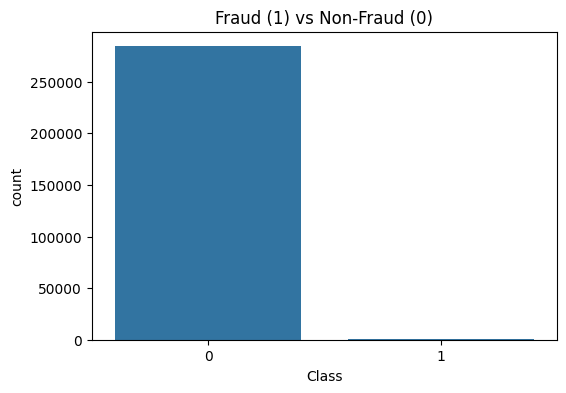

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud (1) vs Non-Fraud (0)")
plt.show()

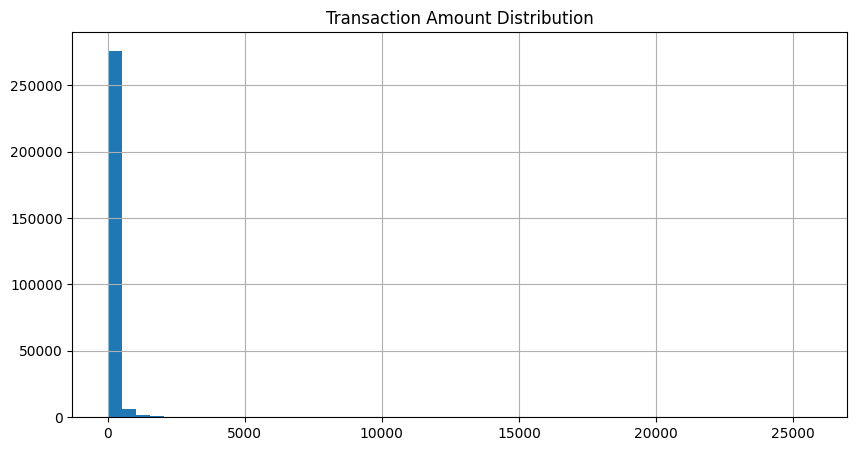

In [7]:
plt.figure(figsize=(10,5))
df['Amount'].hist(bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

# Feature Scaling

In [8]:
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))
df = df.drop(['Time', 'Amount'], axis=1)


# Train-Test Split

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Handle Class Imbalance (SMOTE)

In [10]:
import warnings
warnings.filterwarnings("ignore")

print("\nApplying SMOTE to balance classes...")
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("After SMOTE class distribution:", np.bincount(y_train_res))



Applying SMOTE to balance classes...


  File "C:\Users\shaik\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\shaik\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Users\shaik\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\shaik\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 966, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\shaik\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1435, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


After SMOTE class distribution: [227451 227451]


# Logistic Regression

In [12]:
print("\n===== Logistic Regression =====")
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_res, y_train_res)
y_pred_log = log_model.predict(X_test)
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]))



===== Logistic Regression =====
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9698482164390798


# Random Forest

In [14]:
print("\n===== Random Forest =====")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))



===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9688195357630954


# SVM

In [9]:
print("\n===== SVM (sampled) =====")


sample_size = 20000
sample_idx = np.random.choice(len(X_train_res), size=sample_size, replace=False)

X_svm_train = X_train_res.iloc[sample_idx]
y_svm_train = y_train_res.iloc[sample_idx]

svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_svm_train, y_svm_train)

y_pred_svm = svm_model.predict(X_test)
print(classification_report(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, svm_model.predict_proba(X_test)[:,1]))



===== SVM (sampled) =====
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.09      0.92      0.16        98

    accuracy                           0.98     56962
   macro avg       0.54      0.95      0.57     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.980102184374031


# Outlier Detection


===== Outlier Detection (LOF - Sampled) =====
Detected 20 potential outliers (out of 20000 points).


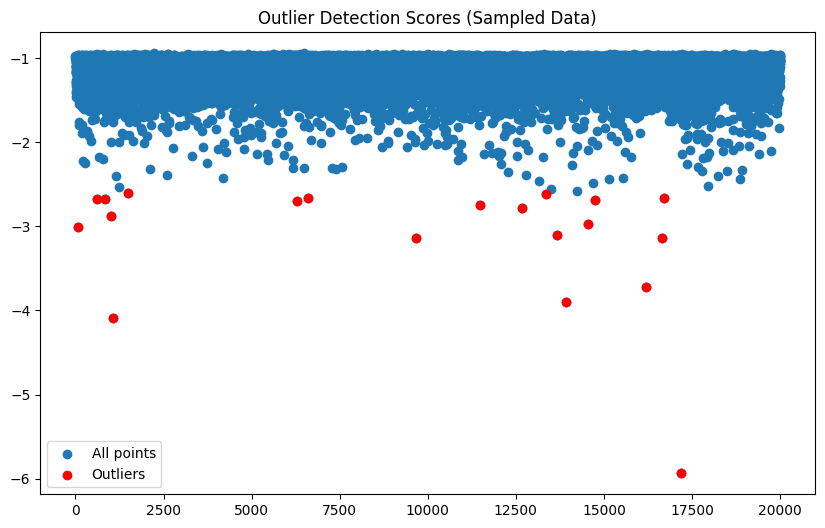

In [11]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np
import matplotlib.pyplot as plt

print("\n===== Outlier Detection (LOF - Sampled) =====")

# Sample 20,000 points for faster processing
sample_size = 20000
sample_idx = np.random.choice(len(X), size=sample_size, replace=False)

X_sample = X.iloc[sample_idx].copy()

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.001)
y_pred_lof = lof.fit_predict(X_sample)

outliers = np.where(y_pred_lof == -1)[0]
print(f"Detected {len(outliers)} potential outliers (out of {sample_size} points).")

plt.figure(figsize=(10,6))
plt.scatter(range(len(lof.negative_outlier_factor_)), lof.negative_outlier_factor_, label='All points')
plt.scatter(outliers, lof.negative_outlier_factor_[outliers], color='red', label='Outliers')
plt.title("Outlier Detection Scores (Sampled Data)")
plt.legend()
plt.show()
